# Real Estate Listings – EDA & Feature Engineering

This notebook explores `real_estate_listings.csv` generated by the scraper.

We will:
- Inspect the data structure and quality
- Perform exploratory data analysis (EDA)
- Engineer useful features for downstream models (e.g., price prediction).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
csv_path = "real_estate_listings.csv"  # assumes this notebook is in the same folder as the CSV

df = pd.read_csv(csv_path)
print(f"Shape: {df.shape}")
display(df.head())

df.info()


Shape: (4000, 10)


,raw_text,price_mru,property_type,time_ago,title_guess,images_count,location,seller,source,url
0,Grand plaza Tevragh Zeina • 9 months ago Share...,2500,NaN,9 months ago,Grand plaza Tevragh Zeina • 9 months ago Share...,NaN,NaN,9 months ago Share Featured 8 جراند بلازا Gran...,voursa,https://voursa.com/EN/categories/real_estate/a...
1,"نيمرو للبيـــع فالصحراوي 6,000,000 MRU Land Pl...",6000000,Land Plot,2 hours ago,نيمرو للبيـــع فالصحراوي,2.0,Tevragh Zeina,سيدي محمد,voursa,https://voursa.com/EN/categories/real_estate/a...
2,"نص نيمرو فالمطار بلوك 59 1,050,000 MRU Land Pl...",1050000,Land Plot,2 hours ago,نص نيمرو فالمطار بلوك 59,1.0,Dar Naim,سيدي محمد,voursa,https://voursa.com/EN/categories/real_estate/a...
3,"نيمرو من بوش 9 أفكرن قريب من كدروه 4,800,000 M...",4800000,Land Plot,2 hours ago,نيمرو من بوش 9 أفكرن قريب من كدروه,1.0,Tevragh Zeina,سيدي محمد,voursa,https://voursa.com/EN/categories/real_estate/a...
4,"نص نيمرو فكرن من شرم الشيخ في البوادي نظيف 1,8...",1800000,Land Plot,2 hours ago,نص نيمرو فكرن من شرم الشيخ في البوادي نظيف,1.0,Teyarett,محمدفال,voursa,https://voursa.com/EN/categories/real_estate/a...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   raw_text       4000 non-null   object 
 1   price_mru      4000 non-null   int64  
 2   property_type  3999 non-null   object 
 3   time_ago       3549 non-null   object 
 4   title_guess    4000 non-null   object 
 5   images_count   3999 non-null   float64
 6   location       3742 non-null   object 
 7   seller         4000 non-null   object 
 8   source         4000 non-null   object 
 9   url            4000 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 312.6+ KB


In [15]:
# Basic numeric summary
numeric_summary = df.describe().T
display(numeric_summary)

# Categorical counts
for col in ["source", "location", "property_type"]:
    if col in df.columns:
        print(f"\nValue counts for {col}:")
        display(df[col].value_counts(dropna=False).head(20))


,count,mean,std,min,25%,50%,75%,max
price_mru,4000.0,4.451755e+06,2.630514e+07,1.0,1150000.0,2700000.0,4600000.0,1.500000e+09
images_count,3999.0,1.673418e+00,1.658839e+00,1.0,1.0,1.0,1.0,1.000000e+01



Value counts for source:


source
voursa    4000
Name: count, dtype: int64


Value counts for location:


location
Tevragh Zeina    2182
Teyarett          684
Dar Naim          446
Arafat            326
NaN               258
Ksar               70
Riyadh             34
Name: count, dtype: int64


Value counts for property_type:


property_type
Land Plot                                2457
Residential Property                     1306
Commercial and Industrial Real Estate     132
Store                                      50
Other                                      27
Office                                     23
Warehouse                                   4
NaN                                         1
Name: count, dtype: int64

## Advanced EDA

In this section we:
- Explore price distributions (including log-price)
- Analyze price by property type and location
- Engineer a numeric time feature from `time_ago`
- Create simple text and image-count features
- Inspect correlations and potential outliers.

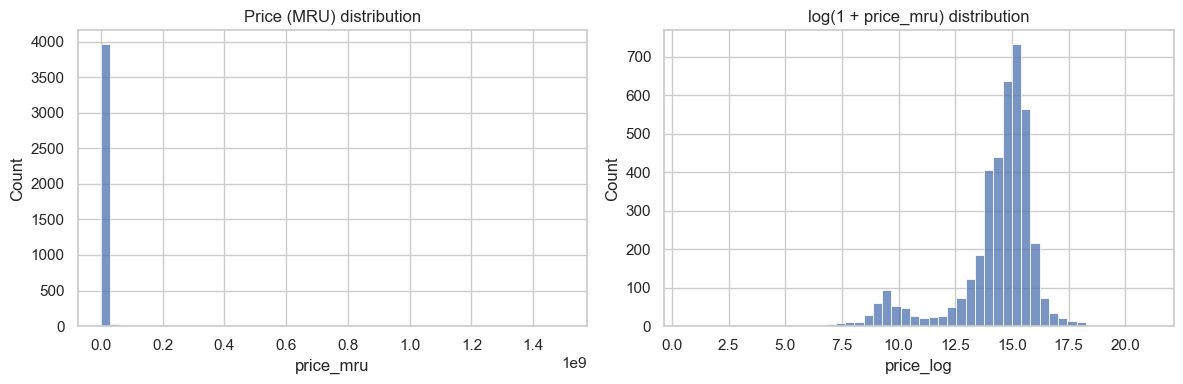

Top 10 most expensive listings (price_mru):


,price_mru,property_type,location,title_guess
627,1500000000,Land Plot,Tevragh Zeina,فرصة بلوك للبيع فاتح عل طريق نواذيبو مناسب لمن...
201,550000000,Residential Property,Tevragh Zeina,ديبلكس
3875,260000000,Residential Property,Tevragh Zeina,دبلكس سكني جميل أخره تصاميم الأنيق
365,115000000,Land Plot,Dar Naim,نيمرو اعلي لبست من المطار القديم للبيع
2658,100000000,Residential Property,Tevragh Zeina,عماره عند سيت اسمار
1975,95000000,Residential Property,Teyarett,عمارة كبيرة جدا للبيع احذا ميبل ول المامي فرصة...
2277,90000000,Commercial and Industrial Real Estate,Tevragh Zeina,اتراب اكبيره للبيع افتفرغ زينه احذ سوق السمك ف...
1260,85000000,Commercial and Industrial Real Estate,Tevragh Zeina,مرصة اعل كدروه جامبور
3184,80000000,Residential Property,Tevragh Zeina,اصتاسيوهات للبيع اعل طريك انواذيب
3836,78000000,Residential Property,Tevragh Zeina,البرتماهاة للبيع في تفر غ زينه قرب مرصة لعلياة


In [16]:
# Price and log-price distributions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["price_mru"], bins=50, ax=axes[0])
axes[0].set_title("Price (MRU) distribution")
axes[0].set_xlabel("price_mru")

# Log-price (helps see structure when there are large values)
df["price_log"] = np.log1p(df["price_mru"])
sns.histplot(df["price_log"], bins=50, ax=axes[1])
axes[1].set_title("log(1 + price_mru) distribution")
axes[1].set_xlabel("price_log")

plt.tight_layout()
plt.show()

# Basic summary of extreme prices
print("Top 10 most expensive listings (price_mru):")
display(df.sort_values("price_mru", ascending=False).head(10)[["price_mru", "property_type", "location", "title_guess"]])

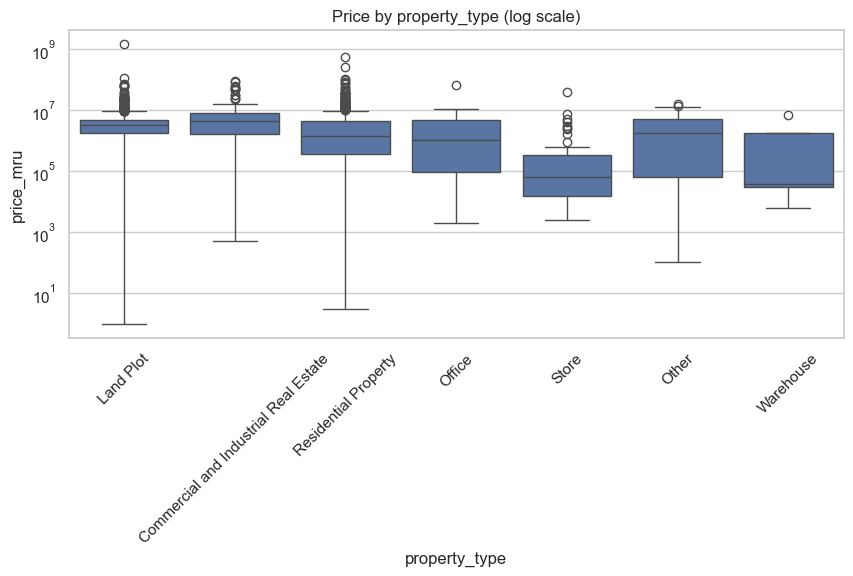

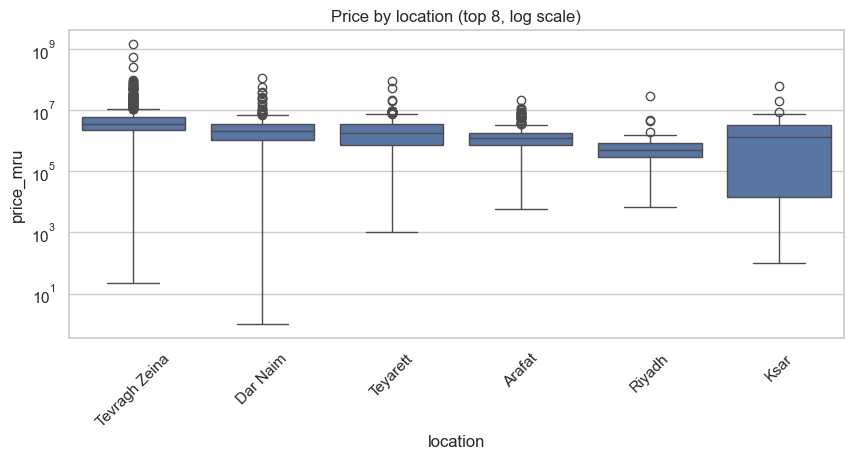

Top locations by count:


location
Tevragh Zeina    2182
Teyarett          684
Dar Naim          446
Arafat            326
Ksar               70
Riyadh             34
Name: count, dtype: int64

In [17]:
# Price by property_type and by location (top locations)

plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="property_type", y="price_mru")
plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Price by property_type (log scale)")
plt.show()

# Focus on top 8 locations to keep plot readable
top_locs = df["location"].value_counts().head(8).index
mask = df["location"].isin(top_locs)

plt.figure(figsize=(10, 4))
sns.boxplot(data=df[mask], x="location", y="price_mru")
plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Price by location (top 8, log scale)")
plt.show()

print("Top locations by count:")
display(df["location"].value_counts().head(15))

       time_ago  hours_since_posted
0  9 months ago              6480.0
1   2 hours ago                 2.0
2   2 hours ago                 2.0
3   2 hours ago                 2.0
4   2 hours ago                 2.0
5   2 hours ago                 2.0
6   2 hours ago                 2.0
7   4 hours ago                 4.0
8   6 hours ago                 6.0
9   6 hours ago                 6.0


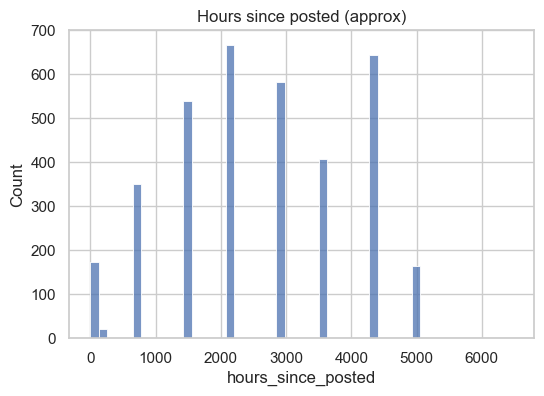

In [18]:
# Numeric time feature from `time_ago`
import re

time_pattern = re.compile(r"(?P<n>\d+)\s+(?P<u>hour|hours|day|days|month|months|year|years)")
unit_to_hours = {
    "hour": 1, "hours": 1,
    "day": 24, "days": 24,
    "month": 30*24, "months": 30*24,
    "year": 365*24, "years": 365*24,
}

def time_ago_to_hours(s):
    if pd.isna(s):
        return np.nan
    m = time_pattern.search(str(s))
    if not m:
        return np.nan
    n = int(m.group("n"))
    u = m.group("u")
    return n * unit_to_hours.get(u, np.nan)

if "time_ago" in df.columns:
    df["hours_since_posted"] = df["time_ago"].apply(time_ago_to_hours)
    print(df[["time_ago", "hours_since_posted"]].head(10))

    plt.figure(figsize=(6,4))
    sns.histplot(df["hours_since_posted"].dropna(), bins=50)
    plt.title("Hours since posted (approx)")
    plt.xlabel("hours_since_posted")
    plt.show()

,title_len_chars,title_len_words,images_count
count,4000.000000,4000.00000,3999.000000
mean,30.227000,5.78975,1.673418
std,14.940575,2.81683,1.658839
min,3.000000,1.00000,1.000000
25%,20.000000,4.00000,1.000000
50%,28.000000,5.00000,1.000000
75%,38.000000,7.00000,1.000000
max,102.000000,21.00000,10.000000


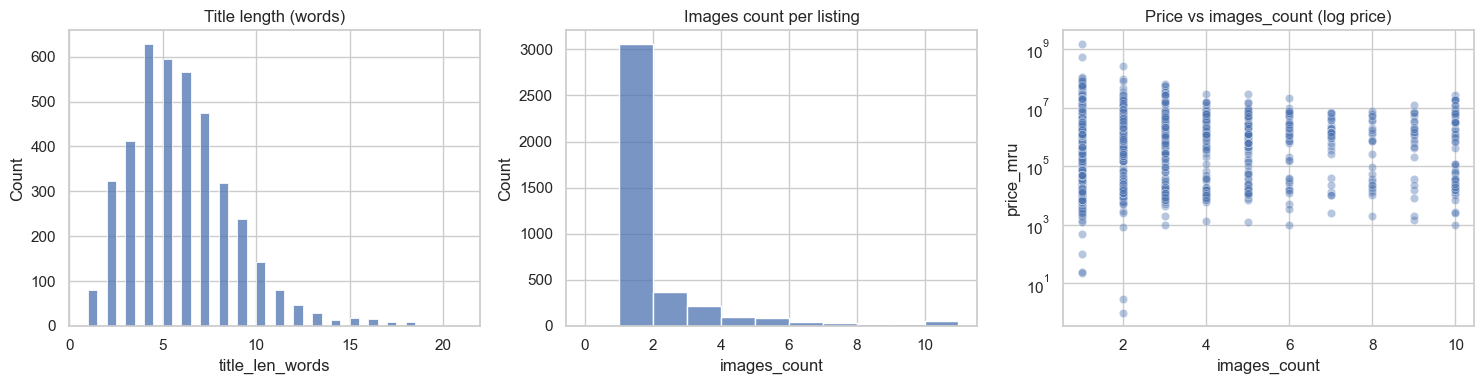

In [19]:
# Text and image-count based features

# Length-based features for the title
df["title_len_chars"] = df["title_guess"].astype(str).str.len()
df["title_len_words"] = df["title_guess"].astype(str).str.split().str.len()

# Basic summaries
display(df[["title_len_chars", "title_len_words", "images_count"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["title_len_words"], bins=40, ax=axes[0])
axes[0].set_title("Title length (words)")

sns.histplot(df["images_count"], bins=range(0, int(df["images_count"].max()) + 2), ax=axes[1])
axes[1].set_title("Images count per listing")

sns.scatterplot(data=df, x="images_count", y="price_mru", alpha=0.4, ax=axes[2])
axes[2].set_yscale("log")
axes[2].set_title("Price vs images_count (log price)")

plt.tight_layout()
plt.show()

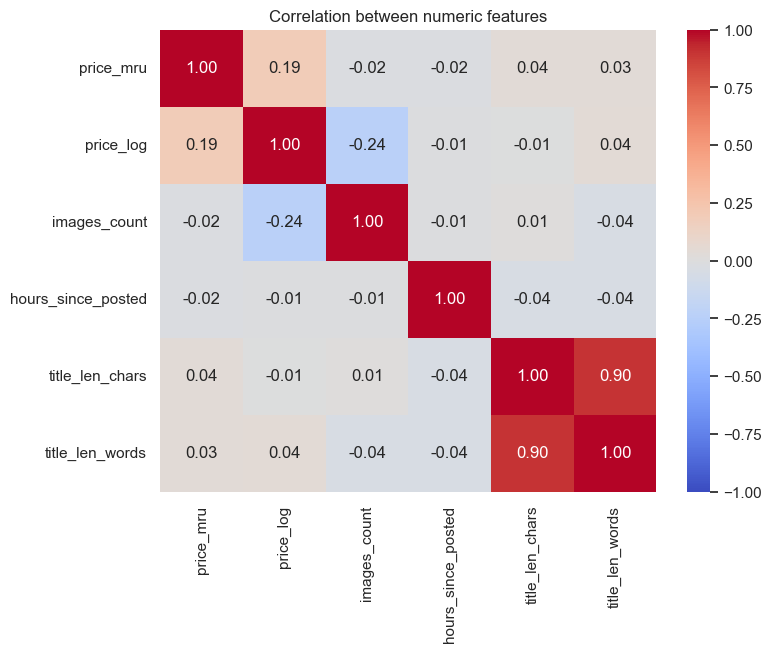

price_mru             1.000000
price_log             0.193903
title_len_chars       0.037951
title_len_words       0.033106
images_count         -0.018047
hours_since_posted   -0.019346
Name: price_mru, dtype: float64

In [20]:
# Correlation matrix for key numeric features

num_cols = [
    col for col in [
        "price_mru", "price_log", "images_count", "hours_since_posted",
        "title_len_chars", "title_len_words",
    ] if col in df.columns
]

corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric features")
plt.show()

corr["price_mru"].sort_values(ascending=False)

In [21]:
# Simple outlier inspection using IQR on price

q1, q3 = df["price_mru"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1={q1:.0f}, Q3={q3:.0f}, IQR={iqr:.0f}, lower={lower_bound:.0f}, upper={upper_bound:.0f}")

outliers = df[df["price_mru"] > upper_bound]
print(f"Number of upper price outliers: {len(outliers)}")

display(outliers.sort_values("price_mru", ascending=False).head(20)[[
    "price_mru", "property_type", "location", "title_guess", "time_ago"
]])

Q1=1150000, Q3=4600000, IQR=3450000, lower=-4025000, upper=9775000
Number of upper price outliers: 185


,price_mru,property_type,location,title_guess,time_ago
627,1500000000,Land Plot,Tevragh Zeina,فرصة بلوك للبيع فاتح عل طريق نواذيبو مناسب لمن...,NaN
201,550000000,Residential Property,Tevragh Zeina,ديبلكس,NaN
3875,260000000,Residential Property,Tevragh Zeina,دبلكس سكني جميل أخره تصاميم الأنيق,7 months ago
365,115000000,Land Plot,Dar Naim,نيمرو اعلي لبست من المطار القديم للبيع,NaN
2658,100000000,Residential Property,Tevragh Zeina,عماره عند سيت اسمار,4 months ago
1975,95000000,Residential Property,Teyarett,عمارة كبيرة جدا للبيع احذا ميبل ول المامي فرصة...,3 months ago
2277,90000000,Commercial and Industrial Real Estate,Tevragh Zeina,اتراب اكبيره للبيع افتفرغ زينه احذ سوق السمك ف...,4 months ago
1260,85000000,Commercial and Industrial Real Estate,Tevragh Zeina,مرصة اعل كدروه جامبور,2 months ago
3184,80000000,Residential Property,Tevragh Zeina,اصتاسيوهات للبيع اعل طريك انواذيب,5 months ago
3836,78000000,Residential Property,Tevragh Zeina,البرتماهاة للبيع في تفر غ زينه قرب مرصة لعلياة,7 months ago


## Wine-style EDA (adapted to real estate data)

This section mirrors the `1.0-WinequalityEDA` notebook style:
- Basic structure and summary
- Missing values and duplicates
- Correlations and heatmap
- Distributions (univariate) and pairwise plots
- Simple categorical plots using `property_type` and `location`.

In [22]:
# Basic summary (structure, describe, shape, columns)

print("\nDataFrame info:\n")
df.info()

print("\nDescriptive statistics (numeric):\n")
display(df.describe().T)

print("\nShape:", df.shape)
print("\nColumns:\n", df.columns.tolist())


DataFrame info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   raw_text            4000 non-null   object 
 1   price_mru           4000 non-null   int64  
 2   property_type       3999 non-null   object 
 3   time_ago            3549 non-null   object 
 4   title_guess         4000 non-null   object 
 5   images_count        3999 non-null   float64
 6   location            3742 non-null   object 
 7   seller              4000 non-null   object 
 8   source              4000 non-null   object 
 9   url                 4000 non-null   object 
 10  price_log           4000 non-null   float64
 11  hours_since_posted  3549 non-null   float64
 12  title_len_chars     4000 non-null   int64  
 13  title_len_words     4000 non-null   int64  
dtypes: float64(3), int64(3), object(8)
memory usage: 437.6+ KB

Descriptive statistics (nu

,count,mean,std,min,25%,50%,75%,max
price_mru,4000.0,4.451755e+06,2.630514e+07,1.000000,1.150000e+06,2.700000e+06,4.600000e+06,1.500000e+09
images_count,3999.0,1.673418e+00,1.658839e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
price_log,4000.0,1.429955e+01,1.854211e+00,0.693147,1.395527e+01,1.480876e+01,1.534157e+01,2.112873e+01
hours_since_posted,3549.0,2.604737e+03,1.372317e+03,2.000000,1.440000e+03,2.880000e+03,3.600000e+03,6.480000e+03
title_len_chars,4000.0,3.022700e+01,1.494057e+01,3.000000,2.000000e+01,2.800000e+01,3.800000e+01,1.020000e+02
title_len_words,4000.0,5.789750e+00,2.816830e+00,1.000000,4.000000e+00,5.000000e+00,7.000000e+00,2.100000e+01



Shape: (4000, 14)

Columns:
 ['raw_text', 'price_mru', 'property_type', 'time_ago', 'title_guess', 'images_count', 'location', 'seller', 'source', 'url', 'price_log', 'hours_since_posted', 'title_len_chars', 'title_len_words']


In [23]:
# Missing values and duplicates

print("\nMissing values per column:\n")
display(df.isnull().sum())

print("\nNumber of duplicated rows:", df.duplicated().sum())

# Show a few duplicates if any
if df.duplicated().any():
    display(df[df.duplicated()].head())


Missing values per column:



raw_text                0
price_mru               0
property_type           1
time_ago              451
title_guess             0
images_count            1
location              258
seller                  0
source                  0
url                     0
price_log               0
hours_since_posted    451
title_len_chars         0
title_len_words         0
dtype: int64


Number of duplicated rows: 0


,price_mru,images_count,price_log,hours_since_posted,title_len_chars,title_len_words
price_mru,1.000000,-0.018047,0.193903,-0.019346,0.037951,0.033106
images_count,-0.018047,1.000000,-0.236226,-0.014083,0.014624,-0.044364
price_log,0.193903,-0.236226,1.000000,-0.009814,-0.007200,0.042410
hours_since_posted,-0.019346,-0.014083,-0.009814,1.000000,-0.040534,-0.043006
title_len_chars,0.037951,0.014624,-0.007200,-0.040534,1.000000,0.903949
title_len_words,0.033106,-0.044364,0.042410,-0.043006,0.903949,1.000000


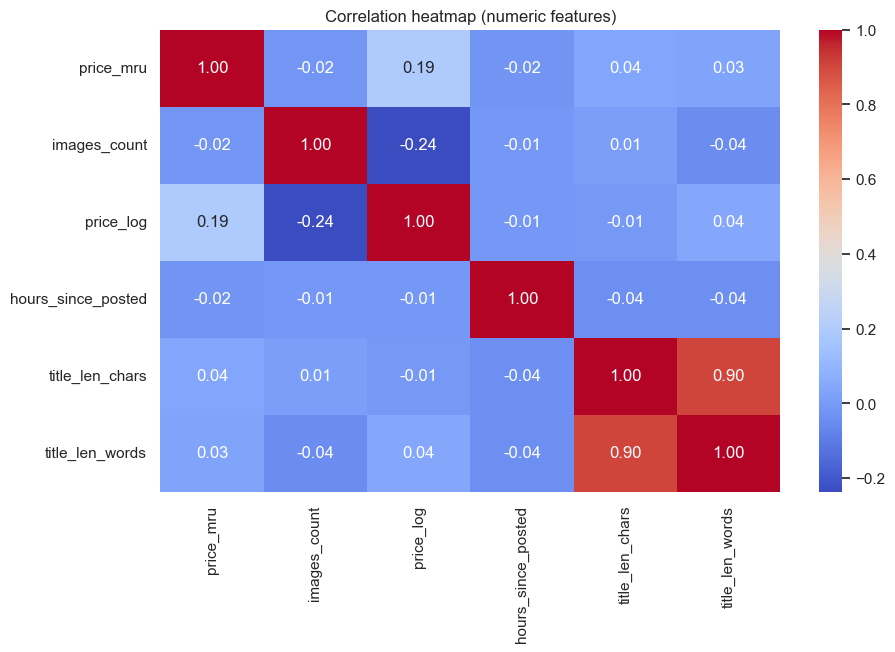

In [24]:
# Correlation matrix and heatmap (all numeric columns)

corr_full = df.corr(numeric_only=True)

display(corr_full)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap (numeric features)")
plt.show()

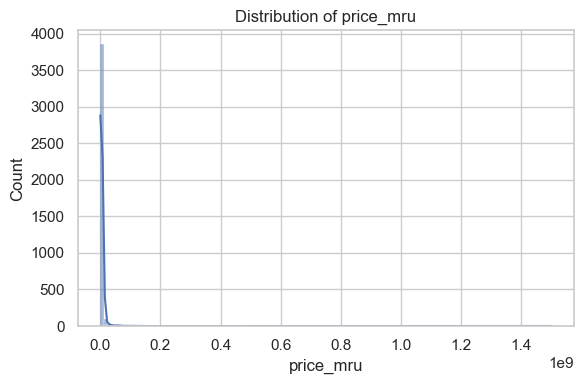

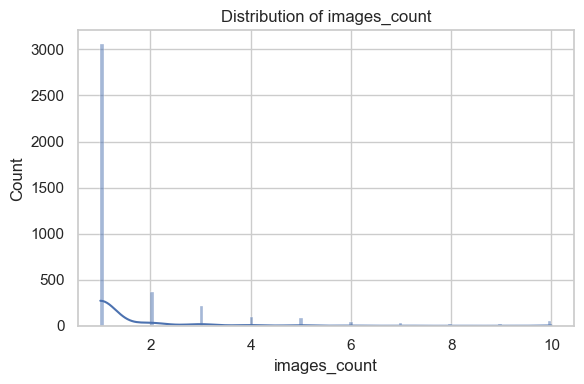

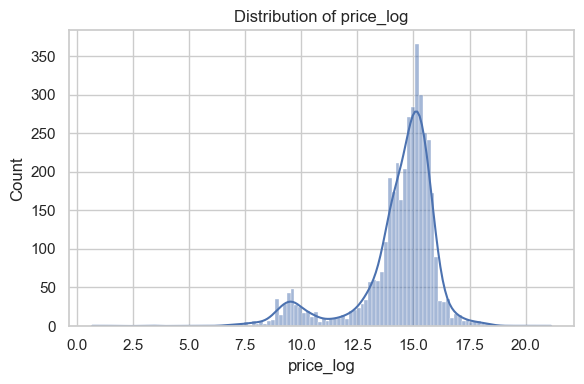

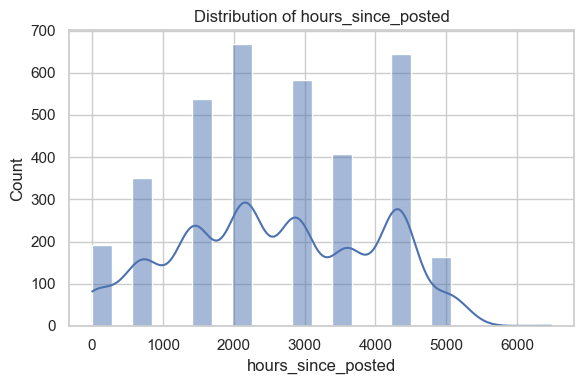

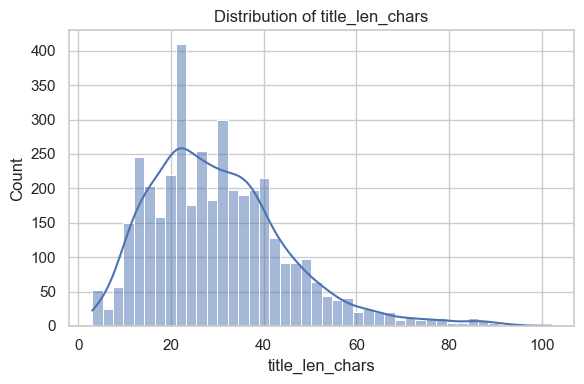

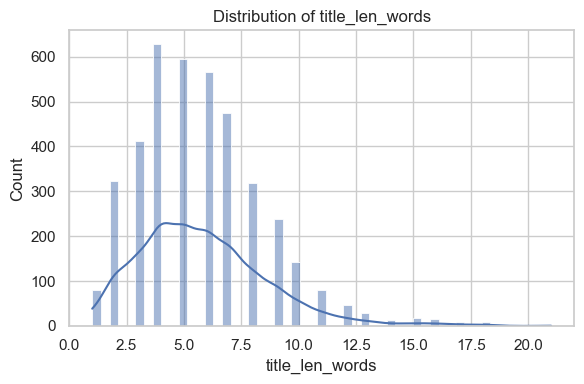

In [25]:
# Univariate distributions for numeric columns (histograms)

numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

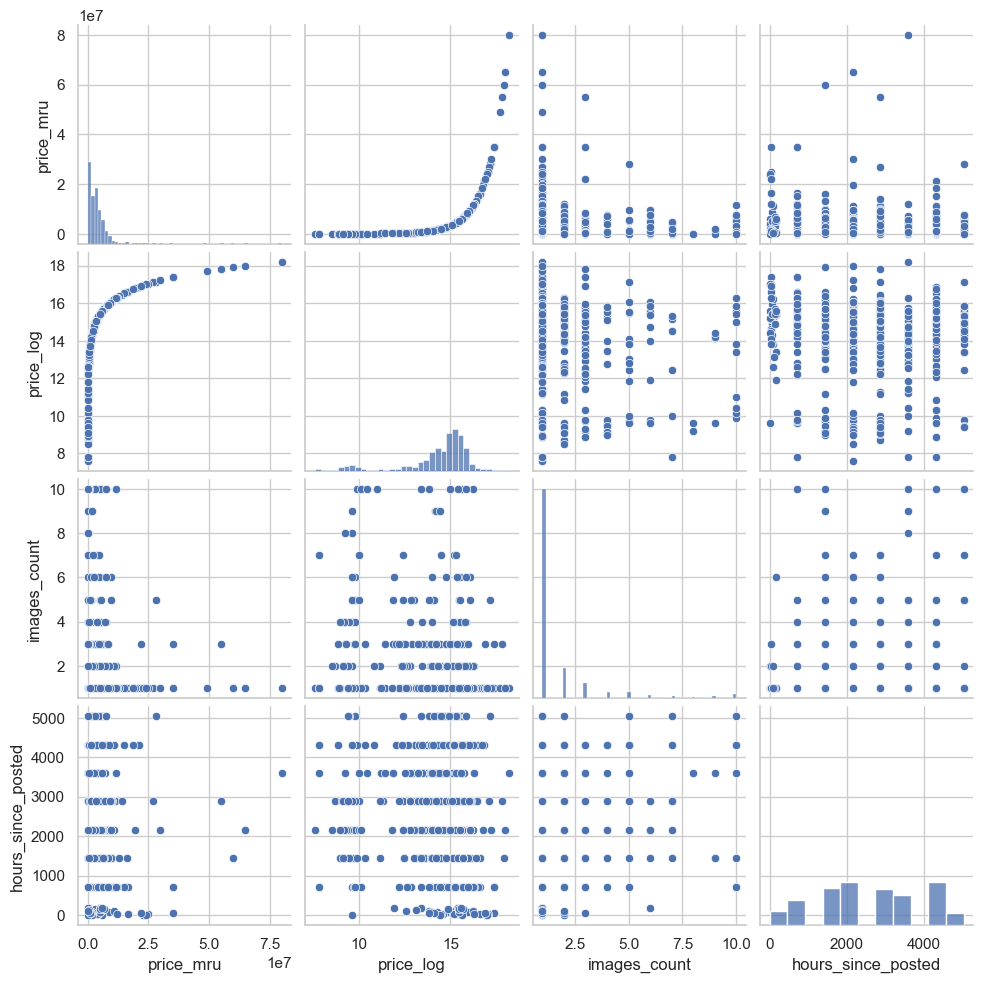

In [26]:
# Pairplot (sampled) to avoid heavy plots

sample_size = min(800, len(df))
df_sample = df.sample(sample_size, random_state=0)

# Focus on key numeric features only
pairplot_cols = [
    col for col in ["price_mru", "price_log", "images_count", "hours_since_posted"] if col in df_sample.columns
]

sns.pairplot(df_sample[pairplot_cols])
plt.show()

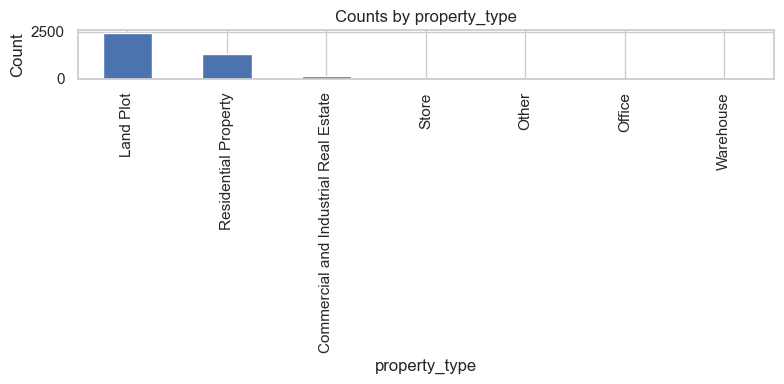

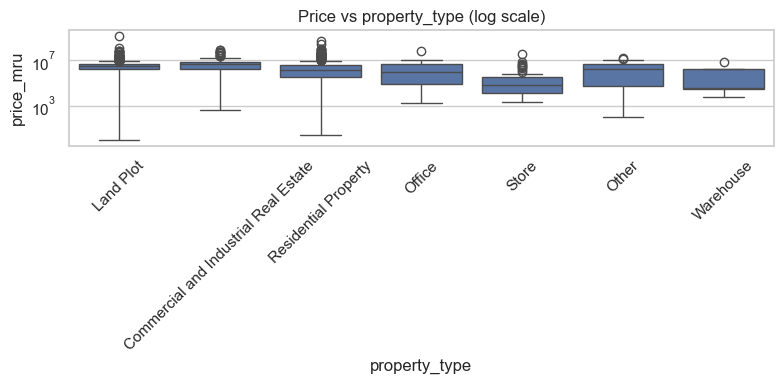

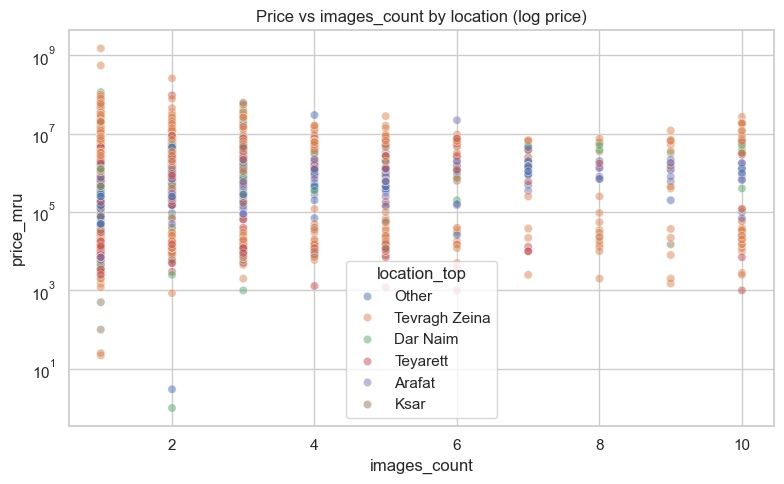

In [27]:
# Categorical-style plots similar to wine quality EDA

# Bar plot: counts by property_type
if "property_type" in df.columns:
    plt.figure(figsize=(8, 4))
    df["property_type"].value_counts().plot(kind="bar")
    plt.xlabel("property_type")
    plt.ylabel("Count")
    plt.title("Counts by property_type")
    plt.tight_layout()
    plt.show()

# Boxplot: price vs property_type
if "property_type" in df.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x="property_type", y="price_mru", data=df)
    plt.yscale("log")
    plt.xticks(rotation=45)
    plt.title("Price vs property_type (log scale)")
    plt.tight_layout()
    plt.show()

# Scatterplot: price vs images_count, colored by top location
if "images_count" in df.columns and "location" in df.columns:
    top_locs = df["location"].value_counts().head(5).index
    df_scatter = df.copy()
    df_scatter["location_top"] = np.where(df_scatter["location"].isin(top_locs), df_scatter["location"], "Other")

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x="images_count", y="price_mru", hue="location_top", data=df_scatter, alpha=0.5)
    plt.yscale("log")
    plt.title("Price vs images_count by location (log price)")
    plt.tight_layout()
    plt.show()